In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import scanpy as sc
import gseapy
import seaborn as sns
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir


In [2]:
adata_dir = large_data_dir + 'MPN_WTA/MPN_1_BC007_genotyped.h5ad'
adata = sc.read_h5ad(adata_dir)

adata.obs['cell_type'] = adata.obs['cell_type'].cat.add_categories(['leukemic blast'])
adata.uns['cell_type_colors'] = np.append(adata.uns['cell_type_colors'], ['#000000'])
### re-name clusters that are in leukemic blast
adata.obs.loc[adata.obs['pheno_leiden'].isin([4,9,16,13,15,17]) & ~(adata.obs['cell_type'].isin(['B cell (non-HSPC)', 'T cell (non-HSPC)'])), 'cell_type'] = 'leukemic blast'

adata.obs['clone'] = pd.read_csv('../output/clone_assignments.csv', index_col=0)['clone']

In [3]:
chr_table = pd.read_csv('../data/hg38_gencode_v27.txt', sep='\t', header=None, on_bad_lines='skip', index_col=0)
chr_table.columns = ['chromosome', 'start','end']
chr_table.loc[(chr_table['chromosome'] == 'chr5') & (chr_table['start'] >= 48800001),'arm'] = 'q'
chr_table.loc[(chr_table['chromosome'] == 'chr5') & (chr_table['start'] < 48800001),'arm'] = 'p'

chr_table.loc[(chr_table['chromosome'] == 'chr13') & (chr_table['start'] >= 17700001),'arm'] = 'q'
chr_table.loc[(chr_table['chromosome'] == 'chr13') & (chr_table['start'] < 17700001),'arm'] = 'p'


In [4]:
DE = {}
res = {}
for cluster in ['8','12','1']:
    DE[cluster] = pd.read_csv('../data/pheno_leiden_' + cluster + '_vs_all_mast_de.csv', index_col=0)
    DE[cluster] = DE[cluster].merge(chr_table, left_on='primerid', right_index=True)
    pre_res = gseapy.prerank(DE[cluster].loc[:,['primerid', 'coef']], gene_sets='MSigDB_Hallmark_2020', verbose=True)
    res[cluster] = pre_res.res2d.copy()

2026-04-12 07:46:04,034 [WARNING] Input gene rankings contains NA values(gene name and ranking value), drop them all!
2026-04-12 07:46:04,042 [INFO] Parsing data files for GSEA.............................
2026-04-12 07:46:04,055 [INFO] Enrichr library gene sets already downloaded in: /home/blattms1/.cache/gseapy, use local file
2026-04-12 07:46:04,061 [INFO] 0001 gene_sets have been filtered out when max_size=500 and min_size=15
2026-04-12 07:46:04,061 [INFO] 0049 gene_sets used for further statistical testing.....
2026-04-12 07:46:04,062 [INFO] Start to run GSEA...Might take a while..................


2026-04-12 07:46:05,364 [INFO] Congratulations. GSEApy runs successfully................

2026-04-12 07:46:05,403 [WARNING] Input gene rankings contains NA values(gene name and ranking value), drop them all!
2026-04-12 07:46:05,411 [INFO] Parsing data files for GSEA.............................
2026-04-12 07:46:05,423 [INFO] Enrichr library gene sets already downloaded in: /home/blattms1/.cache/gseapy, use local file
2026-04-12 07:46:05,429 [INFO] 0001 gene_sets have been filtered out when max_size=500 and min_size=15
2026-04-12 07:46:05,429 [INFO] 0049 gene_sets used for further statistical testing.....
2026-04-12 07:46:05,430 [INFO] Start to run GSEA...Might take a while..................
2026-04-12 07:46:06,693 [INFO] Congratulations. GSEApy runs successfully................

2026-04-12 07:46:06,737 [WARNING] Input gene rankings contains NA values(gene name and ranking value), drop them all!
2026-04-12 07:46:06,742 [INFO] Parsing data files for GSEA.............................
2026

/tmp/ipykernel_2781562/877347997.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heat.fillna(0, inplace=True)


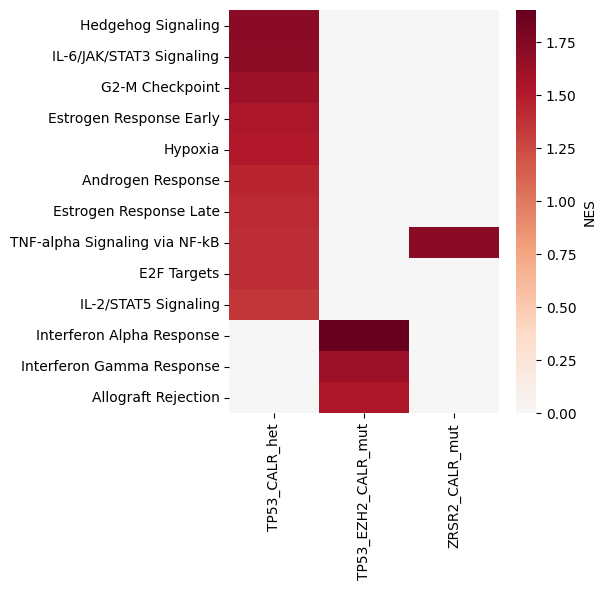

In [ ]:
## heatmap

# helper to standardize each res_* table
def tidy_res(res, clone_name):
    out = res[['Term', 'NES', 'FDR q-val']].copy()
    out['clone'] = clone_name
    return out

long_df = pd.concat([
    tidy_res(res['8'],  'ZRSR2_CALR_mut'),
    tidy_res(res['12'], 'TP53_CALR_het'),
    tidy_res(res['1'],  'TP53_EZH2_CALR_mut')
], ignore_index=True)

# keep significant pathways, or top N per clone
sig = long_df[(long_df['FDR q-val'] < 0.1) & (long_df['NES'] > 0)].copy()
top = (sig.sort_values(['clone', 'NES'], ascending=[True, False])
          .groupby('clone')
          .head(20))  # tweak N

# pivot to matrix: Term x clone
heat = top.pivot_table(index='Term', columns='clone', values='NES')
heat.sort_values(['TP53_CALR_het','TP53_EZH2_CALR_mut','ZRSR2_CALR_mut'], ascending=False, inplace=True)

heat.fillna(0, inplace=True)

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(
    heat,
    cmap='RdBu_r',
    center=0,
    annot=False,
    cbar_kws={'label': 'NES'}, ax=ax
)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()

plt.savefig('../plots/HSC_clone_DE_GSEA_heatmap.pdf')

8
12
1


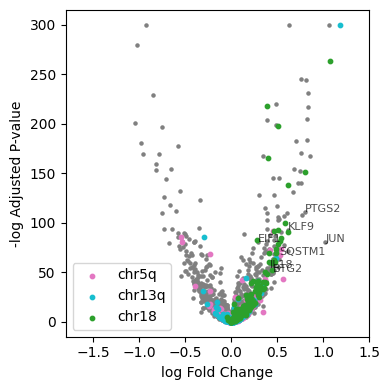

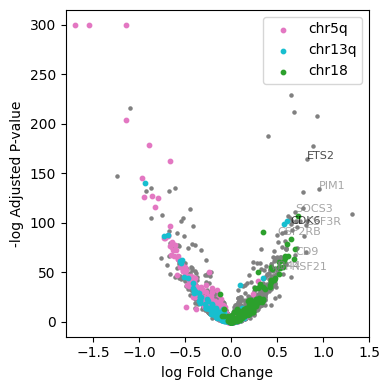

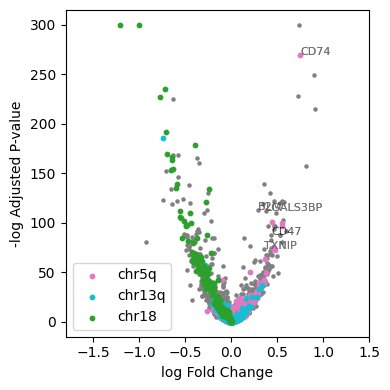

In [ ]:
## volcano plots

s=10
for cluster, df in DE.items():
    print(cluster)
    df['Pr(>Chisq)'] = df['Pr(>Chisq)'] + (1e-300)
    fig,ax = plt.subplots(figsize=(4,4))
    ax.scatter(df['coef'], -np.log10(df['Pr(>Chisq)']), s=5, color='grey')
    ax.scatter(df.loc[(df['chromosome'] == 'chr5') & (df['arm'] == 'q'), 'coef'], -np.log10(df.loc[(df['chromosome'] == 'chr5') & (df['arm'] == 'q'), 'Pr(>Chisq)']), s=s, color='tab:pink', label='chr5q')
    ax.scatter(df.loc[(df['chromosome'] == 'chr13') & (df['arm'] == 'q'), 'coef'], -np.log10(df.loc[(df['chromosome'] == 'chr13') & (df['arm'] == 'q'), 'Pr(>Chisq)']), s=s, color='tab:cyan', label='chr13q')
    ax.scatter(df.loc[df['chromosome'] == 'chr18', 'coef'], -np.log10(df.loc[df['chromosome'] == 'chr18','Pr(>Chisq)']), s=s, color='tab:green', label='chr18')

    pathway_genes = res[cluster].sort_values('NES', ascending=False).head(1)['Lead_genes'].values[0].split(';')
    for gene in pathway_genes:
        sub = df.loc[df['primerid'] == gene]
        if -np.log10(sub['Pr(>Chisq)'].values[0]) > 50:
            ax.text(sub['coef'].values[0], -np.log10(sub['Pr(>Chisq)'].values[0]), gene, fontsize=8, alpha=0.7)

    if cluster in ['12','1']:
        pathway_genes = res[cluster].sort_values('NES', ascending=False).iloc[1]['Lead_genes'].split(';')
        for gene in pathway_genes:
            sub = df.loc[df['primerid'] == gene]
            if -np.log10(sub['Pr(>Chisq)'].values[0]) > 50:
                ax.text(sub['coef'].values[0], -np.log10(sub['Pr(>Chisq)'].values[0]), gene, fontsize=8, alpha=0.7, color = 'grey')

    ax.legend()
    ax.set_xlim(-1.8, 1.5)
    ax.set_xlabel('log Fold Change')
    ax.set_ylabel('-log Adjusted P-value')
    plt.tight_layout()
    plt.savefig('../plots/volcano_' + cluster + '.pdf')
